# Genomics Laboratory

## Solutions Notebook

This notebook contains exercises for the Genomics laboratory session. Complete each exercise by following the step-by-step instructions and filling in the code stubs.

**Learning Objectives:**
- Retrieve genomic data from public databases using REST APIs
- Analyze DNA sequences and compute basic statistics
- Find Transcription-factor binging sites using knonwn binding motifs
- Integrate multi-omics data (genomics, epigenomics)

**Instructions:**
- Read each exercise description carefully
- Follow the step-by-step instructions
- Fill in the code stubs marked with `# TODO:` comments
- Run each cell and verify your results
- Ask for help if you get stuck!

---

## Laboratory Pipeline Overview

1. **Exercise 1: Calling motifs**
   - Find the information about the CTCF binding motif in human (_Homo sapiens_).
   - Download and inspect the Jaspar files.
   - Download the sequence for human chromosome 22 (GRCh38 reference genome) from [Ensembl ftp](https://ftp.ensembl.org/pub/release-115/fasta/homo_sapiens/dna/).
   - Scan the sequence for motif matches, obtaining the score. Plot the score distribution.
   - Select a set of significant motifs. Save their locations to a .bed file along with sequence information.

1. **Exercise 2: Validation using ChIP-seq data**
   - Find the ChIP-seq signal data for the GM12878 CTCF ChIP-seq (Encode accession: ENCFF017XLW).
   - Use the genome browser to preview the signal.
   - Download the significant peaks (we will skep _peak calling_).
   - How well do the identified motifs correspond to the actual ChIP-seq peaks?
   
      - Map peaks to motifs (use `pyranges`).
      - Compute overlaps between peaks and motifs.
      - Show counts and ratios of mapped and unmapped peaks and motifs:
      - Plot motif score vs peak strength for successfull mappings
   
   - Prepare and save a "gold" .bed file with significant motifs that also have strong peaks inside.
   

In [1]:
# Import required libraries
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os

# Configure plotting
plt.style.use('seaborn-v0_8')

# Set up output directory
output_dir = "lab_outputs"
os.makedirs(output_dir, exist_ok=True)

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


## Exercise 1: Calling Motifs

**Goal:** Teach motif databases usage, PWM/PSSM handling, motif scanning, and genomic interval handling.

**Background:**
Transcription factors bind DNA at specific sequence patterns called *motifs*. These motifs are often represented as Position Weight Matrices (PWMs), which describe nucleotide preferences at each position. Databases like JASPAR provide curated motif collections, including the well-known insulator protein CTCF binding motif in humans.

---

### **Task List:**

1. **Retrieve information about the CTCF motif:**

   * Look up the CTCF binding motif for _Homo Sapiens_ in JASPAR (use the one with ID ending with `39.1`).
   * Identify consensus sequence and motif length

2. **Download and inspect motif files:**

   * Download the motif in JASPAR format (PFM)
   * Load the file into Python
   * Convert the Position Frequency Matrix (PFM) into:

     * Position Weight Matrix (PWM)
     * Position-Specific Scoring Matrix (PSSM)
   * Inspect values and verify normalization

3. **Scan a DNA sequence for motif occurrences:**

   * Use ~1Mb sequence around the BRCA1 gene (chr17: 43,000,000-44,000,000)
   * Compute a motif score at each position using the PSSM
   * Remember the reverse strand
   * Store positions and scores

4. **Plot motif score distribution:**

   * Create a histogram of motif scores
   * Plot score vs. sequence position
   * Identify patterns such as peaks or clusters

5. **Select significant motif hits:**

   * Define a threshold (e.g., 0.999 quantile)
   * Filter motif matches above threshold
   * Record:

     * Start and end positions
     * Strand (+/- if scanning both)
     * Motif score
     * Matched sequence

6. **Export motif locations to BED format:**

   * Create a `.bed` file with the following columns:

     * Chromosome (or sequence ID)
     * Start position
     * End position
     * Motif name (e.g., CTCF)
     * Score
     * Strand
     * Matched sequence (optional)


---

### **Key Concepts:**

* Transcription factor binding motifs
* Position Frequency Matrix (PFM), PWM, and PSSM
* Motif scanning algorithms
* Score distributions and thresholding
* Genomic interval formats (BED)
* Biological interpretation of motif hits


In [2]:
import gzip
import biotite.sequence.io.fasta as fasta

# Open gzipped FASTA file in text mode
with open("./lab_outputs/Homo_sapiens.GRCh38.dna.chromosome.17.fa", "r") as f:
    fasta_file = fasta.FastaFile.read(f)

# Extract sequences
for header, full_sequence in fasta_file.items():
    print(header)
    print(full_sequence[:50])


REGION = (42_000_000, 45_000_000)

def get_region_slice(region):
    return slice(region[0] - REGION[0], region[1] - REGION[0])

sequence = full_sequence[REGION[0]:REGION[1]]
sequence[:50]

FileNotFoundError: [Errno 2] No such file or directory: './lab_outputs/Homo_sapiens.GRCh38.dna.chromosome.17.fa'

In [3]:
import requests

def fetch_pfm_jaspar(motif_id):
    """
    Fetch the Position Frequency Matrix (PFM) matrix from JASPAR database.
    
    Parameters:
    - motif_id (str): id of the motif in JASPAR database.
    
    Returns:
    - dict: dictionary with keys 'A', 'C', 'G', 'T' and lists of frequencies
    """
    url = f"https://jaspar.elixir.no/api/v1/matrix/{motif_id.upper()}/?format=json"
    response = requests.get(url)
    
    if not response.ok:
        raise Exception(f"Failed to fetch {motif_id} from JASPAR")
    
    data = response.json()
    pfm = data.get("pfm", None)
    
    return pfm

ctcf_motif_id = 'MA0139.1'
ctcf_jaspar_pfm = fetch_pfm_jaspar(ctcf_motif_id)
print(f"✓ Fetched PFM for motif {ctcf_motif_id} from JASPAR")
print("PFM Matrix:")
for base, freqs in ctcf_jaspar_pfm.items():
    print(f"{base}: {freqs}")

✓ Fetched PFM for motif MA0139.1 from JASPAR
PFM Matrix:
A: [87.0, 167.0, 281.0, 56.0, 8.0, 744.0, 40.0, 107.0, 851.0, 5.0, 333.0, 54.0, 12.0, 56.0, 104.0, 372.0, 82.0, 117.0, 402.0]
C: [291.0, 145.0, 49.0, 800.0, 903.0, 13.0, 528.0, 433.0, 11.0, 0.0, 3.0, 12.0, 0.0, 8.0, 733.0, 13.0, 482.0, 322.0, 181.0]
G: [76.0, 414.0, 449.0, 21.0, 0.0, 65.0, 334.0, 48.0, 32.0, 903.0, 566.0, 504.0, 890.0, 775.0, 5.0, 507.0, 307.0, 73.0, 266.0]
T: [459.0, 187.0, 134.0, 36.0, 2.0, 91.0, 11.0, 324.0, 18.0, 3.0, 9.0, 341.0, 8.0, 71.0, 67.0, 17.0, 37.0, 396.0, 59.0]


In [4]:
def pfm_to_numpy(pfm_dict):
    """
    Convert a PFM dictionary to a numpy array.
    
    Parameters:
    - pfm_dict (dict): dictionary with keys 'A', 'C', 'G', 'T' and lists of frequencies.
    
    Returns:
    - numpy.ndarray: 2D array with shape (4, motif_length) where rows correspond to A, C, G, T.
    """    
    return None

ctcf_pfm = pfm_to_numpy(ctcf_jaspar_pfm)
ctcf_pfm

In [5]:
def pfm_to_pwm(pfm, pseudocount=1e-6):
    """
    Convert Position Frequency Matrix to Position Weight Matrix.

    HINT:
    - Normalize each column so that probabilities sum to 1
    - Add pseudocounts to avoid division by zero
    """
    pwm = None

    return pwm

ctcf_pwm = pfm_to_pwm(ctcf_pfm)
print("PWM as numpy array:")
np.round(ctcf_pwm, 3)

PWM as numpy array:


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

In [6]:
def pwm_to_pssm(pwm, background=0.25):
    """
    Convert PWM to PSSM using log2 odds.

    HINT:
    - PSSM = log2(pwm / background)
    - Background is typically 0.25 for each nucleotide
    """
    pssm = None

    return pssm


ctcf_pssm = pwm_to_pssm(ctcf_pwm)
print("PSSM as numpy array:")
np.round(ctcf_pssm, 2)

PSSM as numpy array:


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

In [ ]:
def scan_sequence(sequence, pssm):
    """
    Scan a DNA sequence with a PSSM.

    Parameters:
        sequence (str): DNA sequence
        pssm (matrix): Position-specific scoring matrix

    Returns:
        Numpy vector of scores for each position in the sequence where the motif can fit.
    """
    assert pssm.shape[0] == 4, "PSSM should have 4 rows corresponding to A, C, G, T"
    base_to_pssm_row = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    n_bases = 4
    seq_length = len(sequence)
    motif_length = pssm.shape[1]

    scores = None
        
    return scores


print('Sanity check:')
print(scan_sequence("TGGCCACCAGGGGGCGCTA", ctcf_pssm))  # 26.1

print('Actual scores for the region:')
pos_scores = scan_sequence(sequence, ctcf_pssm)
pos_scores[:20]

Sanity check:
[26.12031903]
Actual scores for the region:


array([ -30.3373815 ,  -43.04843403,  -46.57667671,  -29.09468152,
        -65.04918437, -100.13823299,  -66.0178233 ,  -42.1034095 ,
        -41.61373966,  -35.91399876,  -23.37170001,  -33.95077381,
        -31.26347221,  -49.32991254,  -40.57497067,  -36.44546095,
        -89.09187968,  -46.78214946,  -29.30263414,  -33.61786678])

quantile 0.999 cutoff: 3.490, potential binding sites above this score: 3000


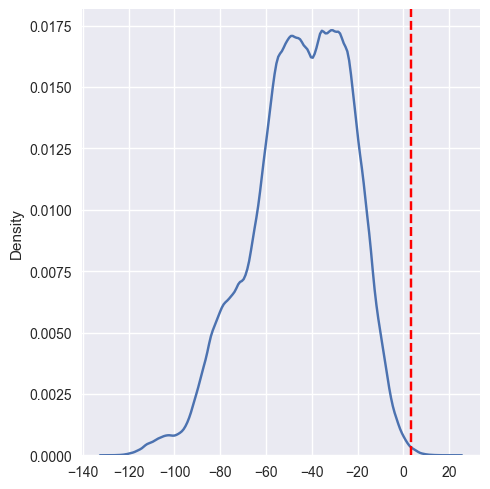

In [ ]:
cutoff = np.quantile(0.999) # 
sns.displot(pos_scores, kind="kde")
plt.axvline(cutoff, color='red', linestyle='--')
print(f"quantile 0.999 cutoff: {cutoff:.3f}, potential binding sites above this score: {np.sum(pos_scores > cutoff)}")

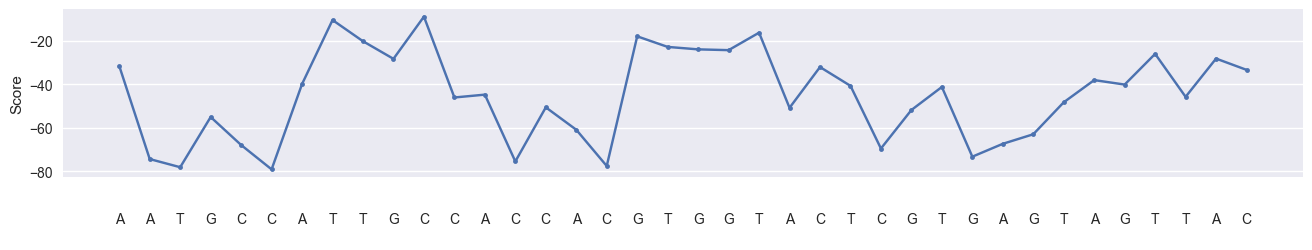

In [37]:
def plot_score_with_sequence(sequence, scores):
    x = range(len(sequence))

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 3),
        sharex=True,
        gridspec_kw={'height_ratios': [4, 1]}
    )

    ax1.plot(x, scores, marker='.')
    ax1.set_ylabel("Score")
    ax1.set_xticks([])  # hide x-axis labels on top plot

    ax2.set_ylim(0, 1)
    ax2.axis('off')

    for i, base in enumerate(sequence):
        ax2.text(i, 0.5, base, ha='center', va='center', fontsize=10)

small_region = (43_084_744, 43_084_782)
plot_score_with_sequence(sequence[get_region_slice(small_region)], pos_scores[get_region_slice(small_region)])
plt.axhline(cutoff, color='red', linestyle='--');

In [ ]:
def save_to_bed(hits, output_file):
    """
    Save motif hits to BED format.

    BED format (6 columns):
    chrom, start, end, name, score, strand

    HINT:
    - start is 0-based
    - end = start + motif_length
    """

    print(f"Saved {len(hits)} hits to {output_file}")